In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np
import scipy as sp

# Standards

In [2]:
Data_PSH = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-2_BO4ACST/GPC/D_ReCreate/PS-H_Standard.csv")

In [3]:
def ConvertPSH_mp_rv(MpValues):
    x = np.array(Data_PSH.rv)
    y = np.log(np.array(Data_PSH.Mp))
    coefficients = np.polyfit(y,x,3)
    p = np.poly1d(coefficients)
    LoggedRvValues = p(np.log(MpValues))
    RvValues = LoggedRvValues
    return RvValues

(4.0, 28.0)

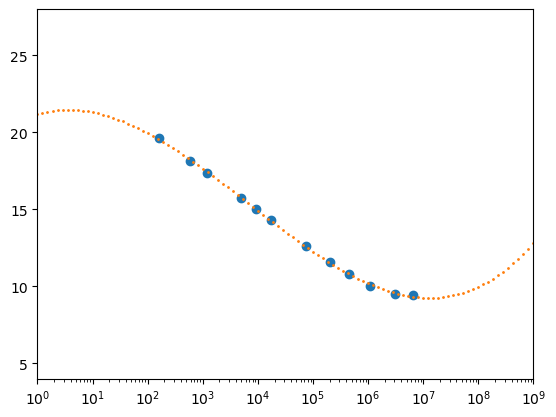

In [4]:
PSHSomeMpValues = np.logspace(0,9,100)
PSHSomeRvValues = ConvertPSH_mp_rv(PSHSomeMpValues)

plt.scatter(Data_PSH.Mp,Data_PSH.rv)
plt.scatter(PSHSomeMpValues,PSHSomeRvValues,s=1)
plt.xlim(1,1000000000)
plt.xscale('log')
plt.ylim(4,28)

(4.0, 28.0)

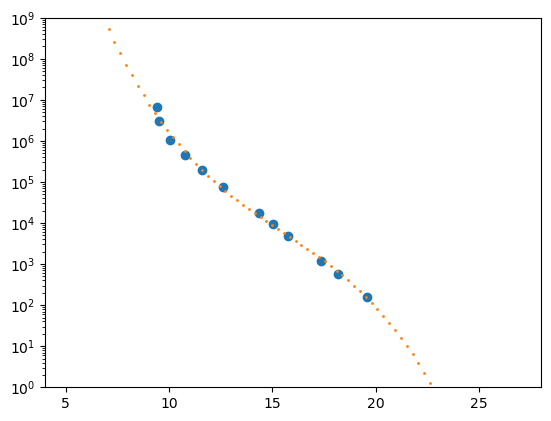

In [5]:
def ConvertPSH_rv_mp(RvValues):
    x = np.array(Data_PSH.rv)
    y = np.log(np.array(Data_PSH.Mp))
    # plt.scatter(x,y)

    coefficients = np.polyfit(x,y,3)
    p = np.poly1d(coefficients)
    xp = np.linspace(np.min(Data_PSH.rv),np.max(Data_PSH.rv),100)
    # plt.scatter(xp,p(xp))
    
    LoggedMpValues = p(RvValues)
    MpValues = np.exp(LoggedMpValues)
    return MpValues

PSHSomeRvValues = np.linspace(0,28,100)
PSHSomeMpValues = ConvertPSH_rv_mp(PSHSomeRvValues)

plt.scatter(Data_PSH.rv,Data_PSH.Mp)
plt.scatter(PSHSomeRvValues,PSHSomeMpValues,s=1)
plt.ylim(1,1000000000)
plt.yscale('log')
plt.xlim(4,28)

# Plotting Standard Overlays

In [6]:
Data_HMWR_PPSI = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-2_BO4ACST/GPC/D_ReCreate/HMWR_PPSI.csv")

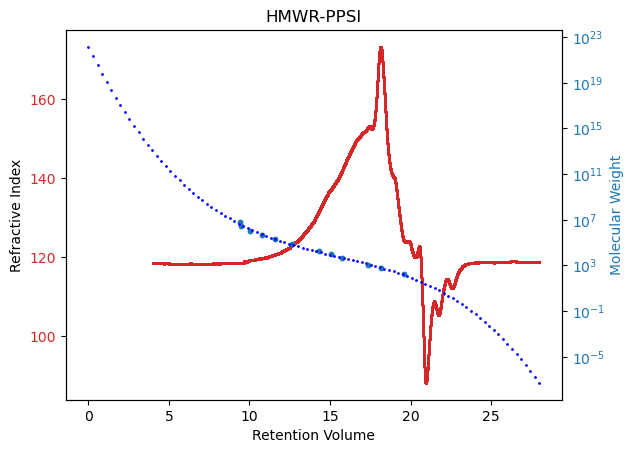

In [7]:
fig, ax1 = plt.subplots()
ax1.set_title("HMWR-PPSI")
color = 'tab:red'
ax1.set_ylabel("Refractive Index")
ax1.set_xlabel("Retention Volume")
ax1.scatter(Data_HMWR_PPSI.rv,Data_HMWR_PPSI.ri,color=color,s=1)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Molecular Weight',color=color)
ax2.scatter(Data_PSH.rv,Data_PSH.Mp,color=color,s=10)
ax2.scatter(PSHSomeRvValues,PSHSomeMpValues,color='blue',s=1)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')

In [8]:
def AnXAxisCutter(LowerLimit,UpperLimit,Dataframe):
    StartIdx = 0
    EndIdx = len(Dataframe)-1
    LowerLimitIdx = 0
    UpperLimitIdx = 0
    for count,i in enumerate(Dataframe.rv):
        if i > LowerLimit:
            LowerLimitIdx = count
            break
    for count,i in enumerate(Dataframe.rv):
        if i > UpperLimit:
            UpperLimitIdx = count
            break
    FirstDropRange = np.linspace(StartIdx,LowerLimitIdx,(LowerLimitIdx-StartIdx)+1).astype(int).tolist()
    SecondDropRange = np.linspace(UpperLimitIdx,EndIdx,(EndIdx-UpperLimitIdx)+1).astype(int).tolist()
    NewDataframe = Dataframe.drop(FirstDropRange)
    NewestDataframe = NewDataframe.drop(SecondDropRange)
    return NewestDataframe

In [9]:
Data_HMWR_PPSI_CutOff = AnXAxisCutter(7.6,20.2,Data_HMWR_PPSI)

# Conversion of X Axes

In [10]:
Data_HMWR_PPSI_rv = np.array(Data_HMWR_PPSI_CutOff.rv).tolist()
Data_HMWR_PPSI_mp = list(reversed(ConvertPSH_rv_mp(Data_HMWR_PPSI_CutOff.rv)))
Data_HMWR_PPSI_ri_init = list(reversed(np.array(Data_HMWR_PPSI_CutOff.ri).tolist()))

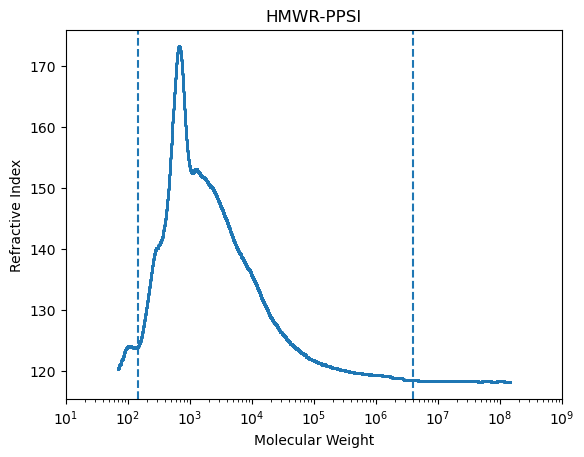

In [11]:
plt.title("HMWR-PPSI")
plt.scatter(Data_HMWR_PPSI_mp,Data_HMWR_PPSI_ri_init,s=1)
plt.xlabel("Molecular Weight")
plt.ylabel("Refractive Index")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
plt.show()

# Baseline Corrected Y Axes

In [12]:
Baseline_HMWR_PPSI = np.array(Data_HMWR_PPSI_ri_init)[-1]

In [13]:
def RemoveBaseline(Baseline,RawData):
    ProcessedData = []
    for i in RawData:
        j = i-Baseline
        if j < 0:
            ProcessedDatum = 0
            ProcessedData.append(ProcessedDatum)
        else:
            ProcessedDatum = j
            ProcessedData.append(ProcessedDatum)
    return ProcessedData

In [14]:
Data_HMWR_PPSI_ri = RemoveBaseline(Baseline_HMWR_PPSI,Data_HMWR_PPSI_ri_init)

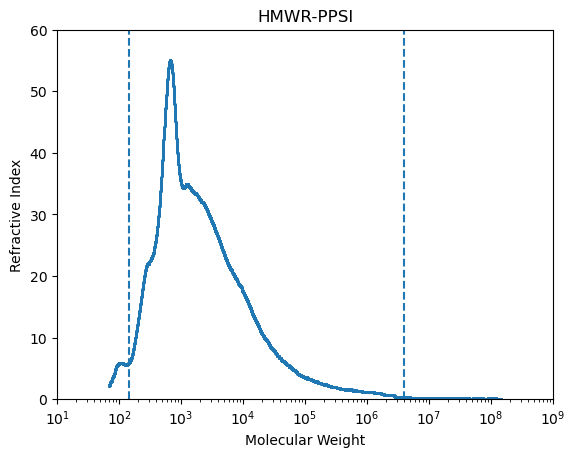

In [15]:
plt.title("HMWR-PPSI")
plt.scatter(Data_HMWR_PPSI_mp,Data_HMWR_PPSI_ri,s=1)
plt.xlabel("Molecular Weight")
plt.ylabel("Refractive Index")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed")
plt.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed")
plt.xscale('log')
plt.xlim(10,1000000000)
plt.ylim(0,60)
plt.show()

# Deconvoluted Refractive Index vs Molecular Weight Curves

In [16]:
df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-2_BO4ACST/GPC/D_ReCreate/HMWR_PPSI_HalfProcessed.csv")
ri = df["RI"]
mw = df["MW"]

In [17]:
def f(x,*params):
    a_1,sigma_1,mu_1 = params[0],params[1],params[2]
    return a_1*(1.0/(x*sigma_1*np.sqrt(2*np.pi))*np.exp(-(np.log(x)-mu_1)**2/(2.0*sigma_1**2)))
def g(x,*params):
    a_2,sigma_2,mu_2 = params[0],params[1],params[2]
    return a_2*(1.0/(x*sigma_2*np.sqrt(2*np.pi))*np.exp(-(np.log(x)-mu_2)**2/(2.0*sigma_2**2)))
def h(x,*params):
    a_3,sigma_3,mu_3 = params[0],params[1],params[2]
    return a_3*(1.0/(x*sigma_3*np.sqrt(2*np.pi))*np.exp(-(np.log(x)-mu_3)**2/(2.0*sigma_3**2)))
def i(x,*params):
    a = f(x,params[0],params[1],params[2])
    b = g(x,params[3],params[4],params[5])
    c = h(x,params[6],params[7],params[8])
    return a+b+c

In [18]:
a_1,sigma_1,mu_1 = 1499460.1847019761,2.208838253388503,11.363747007994624
a_2,sigma_2,mu_2 = 35859.10050735631,0.37248263291909983,6.651042255085735
a_3,sigma_3,mu_3 = 6458.692771491491,0.3621441915584086,5.850105743389885
i_popt,i_pcov = sp.optimize.curve_fit(f=i,xdata=mw,ydata=ri,p0=[a_1,sigma_1,mu_1,a_2,sigma_2,mu_2,a_3,sigma_3,mu_3],maxfev=2000)

(0.0, 57.35049522054508)

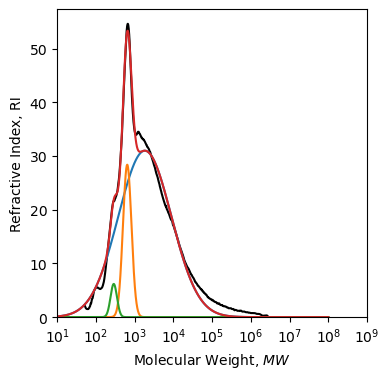

In [19]:
# TrialSamples
TrialXs = np.logspace(start=1,stop=8,num=100000)

fTrialYs = []
for n in TrialXs:
    fTrialYs.append(f(n,i_popt[0],i_popt[1],i_popt[2]))

gTrialYs = []
for n in TrialXs:
    gTrialYs.append(g(n,i_popt[3],i_popt[4],i_popt[5]))

hTrialYs = []
for n in TrialXs:
    hTrialYs.append(h(n,i_popt[6],i_popt[7],i_popt[8]))

iTrialYs = []
for n in TrialXs:
    iTrialYs.append(i(n,i_popt[0],i_popt[1],i_popt[2],i_popt[3],i_popt[4],i_popt[5],i_popt[6],i_popt[7],i_popt[8]))

# PPI
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.set_xlabel(r"Molecular Weight, $MW$")
ax1.set_ylabel(r"Refractive Index, RI")
ax1.plot(mw,ri,color="black")
ax1.plot(TrialXs,fTrialYs)
ax1.plot(TrialXs,gTrialYs)
ax1.plot(TrialXs,hTrialYs)
ax1.plot(TrialXs,iTrialYs)
ax1.tick_params(axis='y')
ax1.set_xscale('log')
ax1.set_xlim(10,1000000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000,1000000000])
ax1.set_ylim(0,np.max(ri)*1.05)

In [20]:
RI_MW_mw = mw
RI_MW_ri = ri
AllCurves_RI_MW_mw = TrialXs
Curve1_RI_MW_ri = hTrialYs
Curve2_RI_MW_ri = gTrialYs
Curve3_RI_MW_ri = fTrialYs
Curves123_RI_MW_ri = np.array(hTrialYs)+np.array(gTrialYs)+np.array(fTrialYs)

# Weight Fraction & Differential Distribution Y Axes

In [21]:
def TotalAreaFinder(MolecularWeightVals,RefractiveIndexVals):
    LasMolWeiVal = MolecularWeightVals[0]
    LasRefIndVal = RefractiveIndexVals[0]
    Areas = []
    for count,(MolWeiVal,RefIndVal) in enumerate(zip(MolecularWeightVals,RefractiveIndexVals)):
        if count == 0:
            continue
        else:
            CurMolWeiVal = MolWeiVal
            DifMolWeiVal = abs(CurMolWeiVal-LasMolWeiVal)
            CurRefIndVal = RefIndVal
            DifRefIndVal = abs(CurRefIndVal-LasRefIndVal)
            LowestRefIndVal = np.min(np.array([CurRefIndVal,LasRefIndVal]))
            TriangularArea = (DifRefIndVal*DifMolWeiVal)/2
            SquareArea = DifMolWeiVal*LowestRefIndVal
            TotalArea = TriangularArea+SquareArea
            Areas.append(TotalArea)
            LasMolWeiVal = CurMolWeiVal
            LasRefIndVal = CurRefIndVal
            continue
    Area = np.sum(np.array(Areas))
    return Area

In [22]:
Area_HMWR_PPSI = TotalAreaFinder(Data_HMWR_PPSI_mp,Data_HMWR_PPSI_ri)
Area_HMWR_PPSI = 100000

In [23]:
def WeightFractionAndDifferentialDistributionFinder(MolecularWeightVals,RefractiveIndexVals,TotRefIndArea):
    LasMolWeiVal = MolecularWeightVals[0]
    LasRefIndVal = RefractiveIndexVals[0]
    NewMolWeiVals = []
    NewWeiFraVals = []
    NewDifDisVals = []
    for count,(MolWeiVal,RefIndVal) in enumerate(zip(MolecularWeightVals,RefractiveIndexVals)):
        if count == 0:
            continue
        else:
            CurMolWeiVal = MolWeiVal
            DifMolWeiVal = abs(CurMolWeiVal-LasMolWeiVal)
            HalDifMolWeiVal = DifMolWeiVal/2
            NewMolWeiVal = CurMolWeiVal+HalDifMolWeiVal
            NewMolWeiVals.append(NewMolWeiVal)
            
            CurRefIndVal = RefIndVal
            DifRefIndVal = abs(CurRefIndVal-LasRefIndVal)
            HalDifRefIndVal = DifRefIndVal/2
            LowestRefIndVal = np.min(np.array([CurRefIndVal,LasRefIndVal]))
            NewRefIndVal = LowestRefIndVal+HalDifRefIndVal

            NewWeiFraVal = NewRefIndVal/TotRefIndArea
            NewWeiFraVals.append(NewWeiFraVal)

            LogDifMolWeiVal = np.log(CurMolWeiVal)-np.log(LasMolWeiVal)
            NewDifDisVal = NewWeiFraVal/LogDifMolWeiVal
            NewDifDisVals.append(NewDifDisVal)
            
            LasMolWeiVal = CurMolWeiVal
            LasRefIndVal = CurRefIndVal
            continue
    return NewMolWeiVals,NewWeiFraVals,NewDifDisVals

In [24]:
Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_wf_Mod,Data_HMWR_PPSI_dd_Mod = WeightFractionAndDifferentialDistributionFinder(Data_HMWR_PPSI_mp,Data_HMWR_PPSI_ri,Area_HMWR_PPSI)

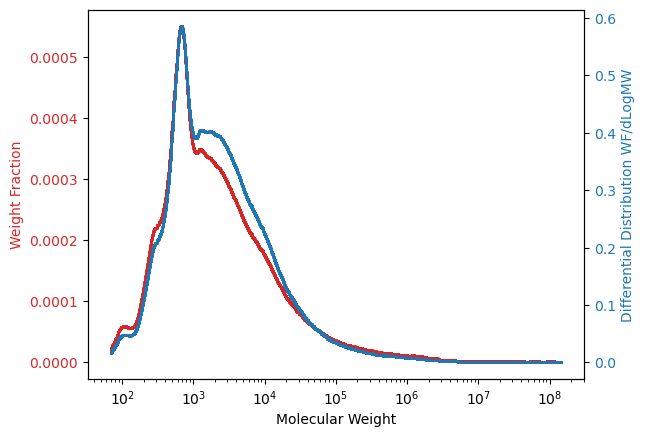

In [25]:
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.set_ylabel('Weight Fraction',color=color)
ax1.set_xlabel('Molecular Weight')
ax1.scatter(Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_wf_Mod,s=1,label="PPSI",color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Differential Distribution WF/dLogMW',color=color)
ax2.scatter(Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_dd_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

# Deconvoluted Differential Distributions

In [26]:
df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-2_BO4ACST/GPC/D_ReCreate/HMWR_PPSI_Processed.csv")
mw = df["MW"]
wf = df["WF"]

In [27]:
def f(x,*params):
    a_1,sigma_1,mu_1 = params[0],params[1],params[2]
    return a_1*(1.0/(sigma_1*np.sqrt(2*np.pi))*np.exp(-(np.log(x)-mu_1)**2/(2.0*sigma_1**2)))

def g(x,*params):
    a_2,sigma_2,mu_2 = params[0],params[1],params[2]
    return a_2*(1.0/(sigma_2*np.sqrt(2*np.pi))*np.exp(-(np.log(x)-mu_2)**2/(2.0*sigma_2**2)))

def h(x,*params):
    a_3,sigma_3,mu_3 = params[0],params[1],params[2]
    return a_3*(1.0/(sigma_3*np.sqrt(2*np.pi))*np.exp(-(np.log(x)-mu_3)**2/(2.0*sigma_3**2)))

def i(x,*params):
    a = f(x,params[0],params[1],params[2])
    b = g(x,params[3],params[4],params[5])
    c = h(x,params[6],params[7],params[8])
    return a+b+c

In [28]:
a_1,sigma_1,mu_1 = 9008.208396471862,1.4916304979418271,9.859144222675075
a_2,sigma_2,mu_2 = 112.03139998040794,0.2332572982460652,6.537294467000857
a_3,sigma_3,mu_3 = 5.750278316040288,0.17915869906311715,5.727003945281524
i_popt,i_pcov = sp.optimize.curve_fit(f=i,xdata=mw,ydata=wf,p0=[a_1,sigma_1,mu_1,a_2,sigma_2,mu_2,a_3,sigma_3,mu_3],maxfev=2000)

(0.0, 0.6107389445673804)

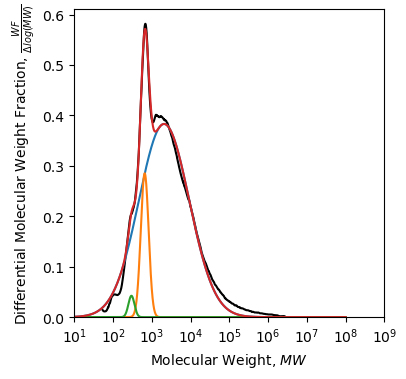

In [111]:
# TrialSamples
# TrialXs = np.logspace(start=1,stop=8,num=10000)
TrialsXs = np.linspace(start=10,stop=100000000,num=10000)

fTrialYs = []
for n in TrialXs:
    fTrialYs.append(f(n,i_popt[0],i_popt[1],i_popt[2]))

gTrialYs = []
for n in TrialXs:
    gTrialYs.append(g(n,i_popt[3],i_popt[4],i_popt[5]))

hTrialYs = []
for n in TrialXs:
    hTrialYs.append(h(n,i_popt[6],i_popt[7],i_popt[8]))

iTrialYs = []
for n in TrialXs:
    iTrialYs.append(i(n,i_popt[0],i_popt[1],i_popt[2],i_popt[3],i_popt[4],i_popt[5],i_popt[6],i_popt[7],i_popt[8]))

# PPI
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.set_xlabel(r"Molecular Weight, $MW$")
ax1.set_ylabel(r"Differential Molecular Weight Fraction, $\frac{WF}{\Delta log(MW)}$")
ax1.plot(mw,wf,color="black")
ax1.plot(TrialXs,fTrialYs)
ax1.plot(TrialXs,gTrialYs)
ax1.plot(TrialXs,hTrialYs)
ax1.plot(TrialXs,iTrialYs)
ax1.tick_params(axis='y')
ax1.set_xscale('log')
ax1.set_xlim(10,1000000000)
ax1.set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000,1000000000])
ax1.set_ylim(0,np.max(wf)*1.05)

In [112]:
DMWF_MW_mw = mw
DMWF_MW_dmwf = wf
AllCurves_DMWF_MW_mw = TrialXs
Curve1_DMWF_MW_dmwf = hTrialYs
Curve2_DMWF_MW_dmwf = gTrialYs
Curve3_DMWF_MW_dmwf = fTrialYs
Curves123_DMWF_MW_dmwf = np.array(hTrialYs)+np.array(gTrialYs)+np.array(fTrialYs)

# Cumulative Weight Fraction

In [113]:
def CumulativeWeightFractionFinder(WeightFractionValues):
    CumulativeWeightFractions = []
    RunningWeightFraction = WeightFractionValues[0]
    for count,WeiFraVal in enumerate(WeightFractionValues):
        if count == 0:
            CumulativeWeightFractions.append(RunningWeightFraction)
            continue
        else:
            NewCumWeiFrac = RunningWeightFraction+WeiFraVal
            CumulativeWeightFractions.append(NewCumWeiFrac)
            RunningWeightFraction = NewCumWeiFrac
            continue
    TotalWeightFractions = CumulativeWeightFractions[-1]
    CumulativeNormalisedWeightFractions = np.array(CumulativeWeightFractions)/TotalWeightFractions
    return CumulativeNormalisedWeightFractions,TotalWeightFractions

In [114]:
Data_HMWR_PPSI_cwf_Mod,HMWR_PPSI_TotalWeightFractions = CumulativeWeightFractionFinder(Data_HMWR_PPSI_wf_Mod)

In [115]:
print("The total weight fractions of the various curves:")
print(f"HMWR-PPSI:\t{round(HMWR_PPSI_TotalWeightFractions,2)}")

The total weight fractions of the various curves:
HMWR-PPSI:	1.68


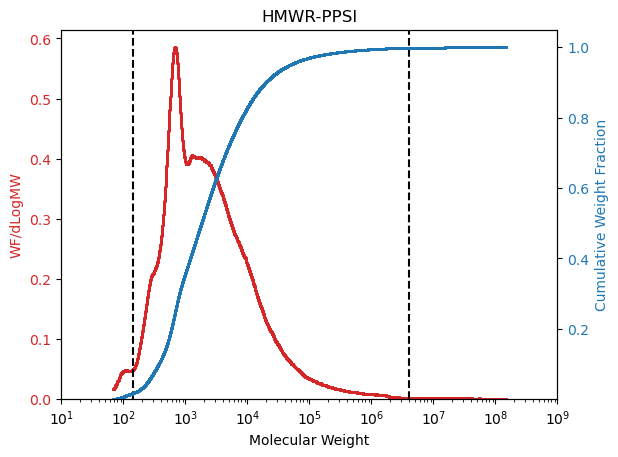

In [116]:
fig, ax1 = plt.subplots()
ax1.set_title("HMWR-PPSI")
color = 'tab:red'
ax1.set_xlabel("Molecular Weight")
ax1.set_ylabel("WF/dLogMW",color=color)
ax1.scatter(Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_dd_Mod,s=1,color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color='tab:blue'
ax2.set_ylabel('Cumulative Weight Fraction',color=color)
ax2.scatter(Data_HMWR_PPSI_mp_Mod,Data_HMWR_PPSI_cwf_Mod,color=color,s=1)
ax2.tick_params(axis='y', labelcolor=color)

ax1.set_xlim(10,1000000000)
ax1.set_ylim(np.min(Data_HMWR_PPSI_dd_Mod),np.max(Data_HMWR_PPSI_dd_Mod)*1.05)
ax2.set_ylim(np.min(Data_HMWR_PPSI_cwf_Mod),np.max(Data_HMWR_PPSI_cwf_Mod)*1.05)
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.min(Data_PSH.rv)]),linestyle="dashed",color="black")
ax1.axvline(ymin=0,ymax=1,x=ConvertPSH_rv_mp([np.max(Data_PSH.rv)]),linestyle="dashed",color="black")

# Finding Average Molecular Weights

In [117]:
def MolecularWeightFinder(RelativeIntensityData,RetentionVolumeData,MolecularMassData,IterativeSteps):
    MaximumRetentionVolume = np.max(RetentionVolumeData)
    MinimumRetentionVolume = np.min(RetentionVolumeData)
    RetentionVolumeRange = MaximumRetentionVolume-MinimumRetentionVolume
    VolumePerStep = RetentionVolumeRange/IterativeSteps

    IterativelyProducedAverages_ri = []
    IterativelyProducedAverages_mp = []
    CurrentVolume = MinimumRetentionVolume
    for step in range(IterativeSteps):
        if step+1 == IterativeSteps:
            LowerVolumeLimit = CurrentVolume
            UpperVolumeLimit = CurrentVolume+VolumePerStep

            LowerVolumeLimitIdx = 0
            for count,RetentionVolumeDatum in enumerate(RetentionVolumeData):
                if RetentionVolumeDatum > LowerVolumeLimit:
                    LowerVolumeLimitIdx = count
                    break

            UpperVolumeLimitIdx = len(RetentionVolumeData)-1

            VolumeIdxRange = np.linspace(LowerVolumeLimitIdx,UpperVolumeLimitIdx,(UpperVolumeLimitIdx-LowerVolumeLimitIdx)+1).astype('int').tolist()
            
            Filtered_ri = np.array(RelativeIntensityData)[VolumeIdxRange]
            Filtered_mp = np.array(MolecularMassData)[VolumeIdxRange]

            ri_avg = np.average(Filtered_ri)
            mp_avg = np.average(Filtered_mp)

            IterativelyProducedAverages_ri.append(ri_avg)
            IterativelyProducedAverages_mp.append(mp_avg)
            break
        else:
            LowerVolumeLimit = CurrentVolume
            UpperVolumeLimit = CurrentVolume+VolumePerStep

            LowerVolumeLimitIdx = 0
            UpperVolumeLimitIdx = 0

            for count,RetentionVolumeDatum in enumerate(RetentionVolumeData):
                if RetentionVolumeDatum > LowerVolumeLimit:
                    LowerVolumeLimitIdx = count
                    break
                
            for count,RetentionVolumeDatum in enumerate(RetentionVolumeData):
                if RetentionVolumeDatum > UpperVolumeLimit:
                    UpperVolumeLimitIdx = count
                    break

            VolumeIdxRange = np.linspace(LowerVolumeLimitIdx,UpperVolumeLimitIdx,(UpperVolumeLimitIdx-LowerVolumeLimitIdx)+1).astype('int').tolist()
            
            Filtered_ri = np.array(RelativeIntensityData)[VolumeIdxRange]
            Filtered_mp = np.array(MolecularMassData)[VolumeIdxRange]

            ri_avg = np.average(Filtered_ri)
            mp_avg = np.average(Filtered_mp)

            IterativelyProducedAverages_ri.append(ri_avg)
            IterativelyProducedAverages_mp.append(mp_avg)

            CurrentVolume = UpperVolumeLimit
            continue

    # Number Average Molecular Weight
    a = np.sum(IterativelyProducedAverages_ri)
    b = np.array(IterativelyProducedAverages_ri)
    c = np.array(IterativelyProducedAverages_mp)
    d = b/c
    e = np.sum(d)
    f = a/e

    # Weight Average Molecular Weight
    g = b*c
    h = np.sum(g)
    i = h/a

    # Dispersity
    j = i/f

    return f,i,j # number average, weight average, dispersity

In [118]:
IterativeSteps = 1000
HMWR_PPSI_NumAveMolWei,HMWR_PPSI_WeiAveMolWei,HMWR_PPSI_Disp = MolecularWeightFinder(Data_HMWR_PPSI_ri,Data_HMWR_PPSI_rv,Data_HMWR_PPSI_mp,IterativeSteps)
Distrib1_PPSI_NumAveMolWei,Distrib1_PPSI_WeiAveMolWei,Distrib1_PPSI_Disp = MolecularWeightFinder(Curve1_RI_MW_ri,list(reversed(ConvertPSH_mp_rv(AllCurves_RI_MW_mw))),AllCurves_RI_MW_mw,IterativeSteps)
Distrib2_PPSI_NumAveMolWei,Distrib2_PPSI_WeiAveMolWei,Distrib2_PPSI_Disp = MolecularWeightFinder(Curve2_RI_MW_ri,list(reversed(ConvertPSH_mp_rv(AllCurves_RI_MW_mw))),AllCurves_RI_MW_mw,IterativeSteps)
Distrib3_PPSI_NumAveMolWei,Distrib3_PPSI_WeiAveMolWei,Distrib3_PPSI_Disp = MolecularWeightFinder(Curve3_RI_MW_ri,list(reversed(ConvertPSH_mp_rv(AllCurves_RI_MW_mw))),AllCurves_RI_MW_mw,IterativeSteps)

In [119]:
print(f"\t\tNumber Average Mr\tWeight Average Mr\tDispersity")
print(f"Apparent:\t{round(HMWR_PPSI_NumAveMolWei,2)}\t\t\t{round(HMWR_PPSI_WeiAveMolWei,2)}\t\t{round(HMWR_PPSI_Disp,2)}")
print(f"Distribution1:\t{round(Distrib1_PPSI_NumAveMolWei,2)}\t\t\t{round(Distrib1_PPSI_WeiAveMolWei,2)}\t\t\t{round(Distrib1_PPSI_Disp,2)}")
print(f"Distribution2:\t{round(Distrib2_PPSI_NumAveMolWei,2)}\t\t\t{round(Distrib2_PPSI_WeiAveMolWei,2)}\t\t\t{round(Distrib2_PPSI_Disp,2)}")
print(f"Distribution3:\t{round(Distrib3_PPSI_NumAveMolWei,2)}\t\t\t{round(Distrib3_PPSI_WeiAveMolWei,2)}\t\t{round(Distrib3_PPSI_Disp,2)}")

		Number Average Mr	Weight Average Mr	Dispersity
Apparent:	887.6			79124.53		89.14
Distribution1:	163.79			163.95			1.0
Distribution2:	812.86			849.64			1.05
Distribution3:	2054.72			10394.43		5.06


# hell

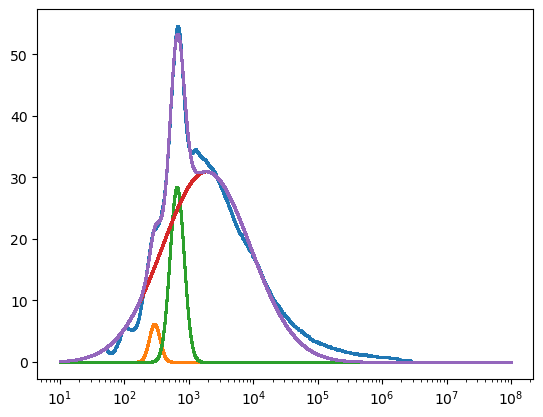

In [177]:
plt.scatter(RI_MW_mw,RI_MW_ri,s=1)
plt.scatter(AllCurves_RI_MW_mw,Curve1_RI_MW_ri,s=1)
plt.scatter(AllCurves_RI_MW_mw,Curve2_RI_MW_ri,s=1)
plt.scatter(AllCurves_RI_MW_mw,Curve3_RI_MW_ri,s=1)
plt.scatter(AllCurves_RI_MW_mw,Curves123_RI_MW_ri,s=1)
plt.xscale('log')